# IMPORTING LIBRARIES

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

# LOADING THE DATASET

In [3]:
# creating database connection
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis

- previously, we examined the various table in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysi
-  in this phase of EDA, we will analyze the resultant table to gain insights into the distribution of rach column. this will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with futher analysis.


In [4]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


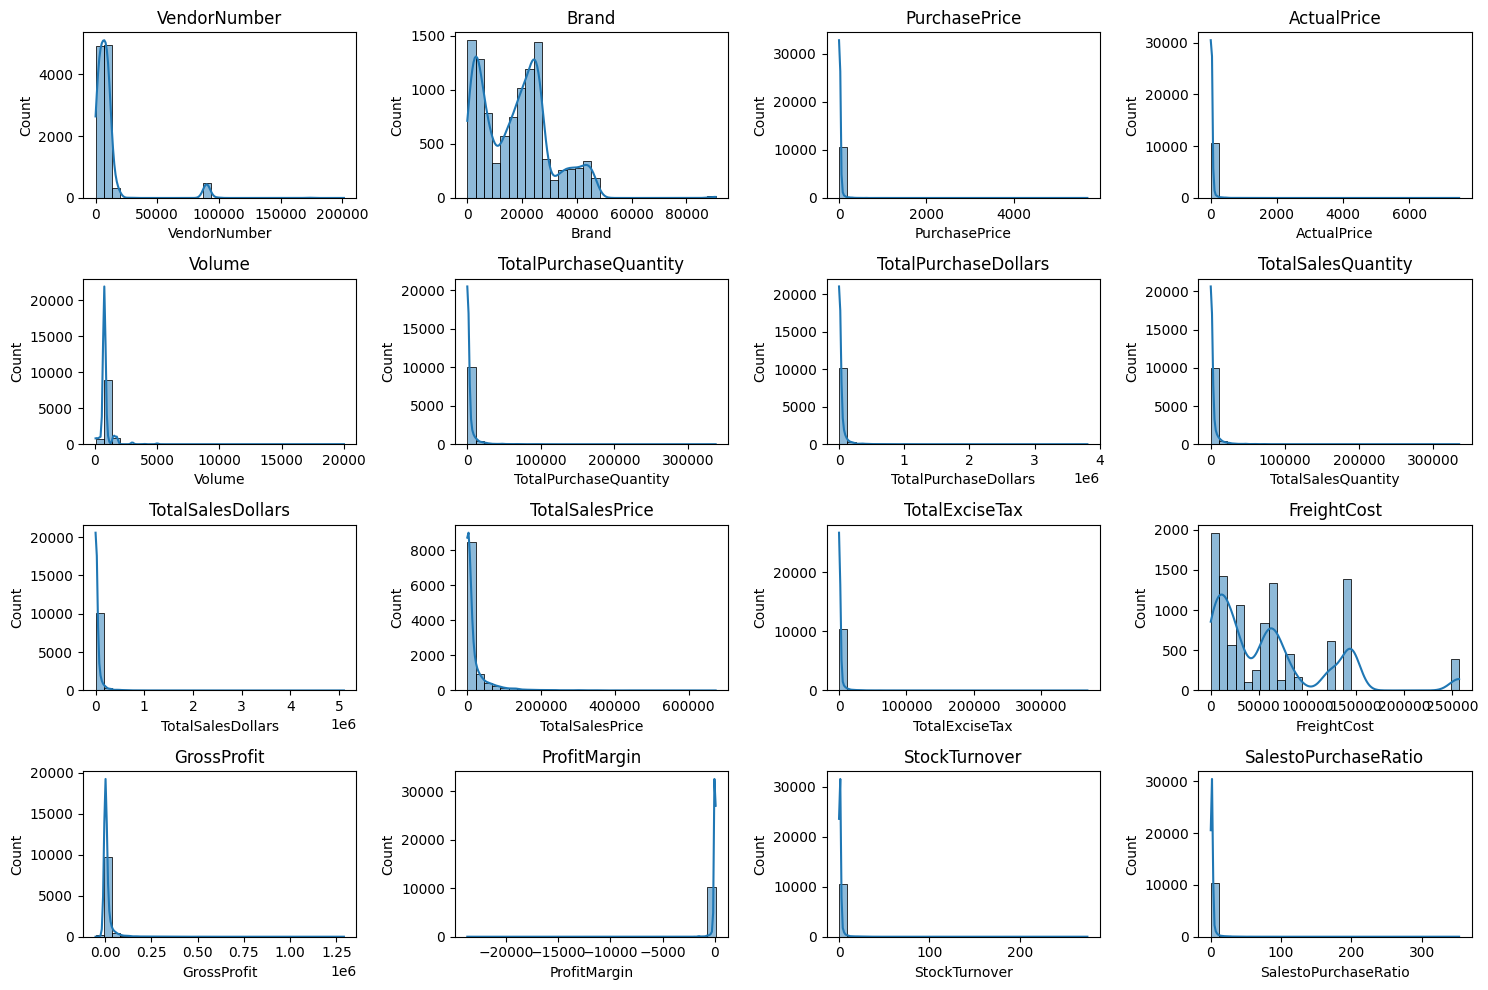

In [5]:
# Distribution Plots for Numerical columns 
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # adjust grid layout as needed 
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

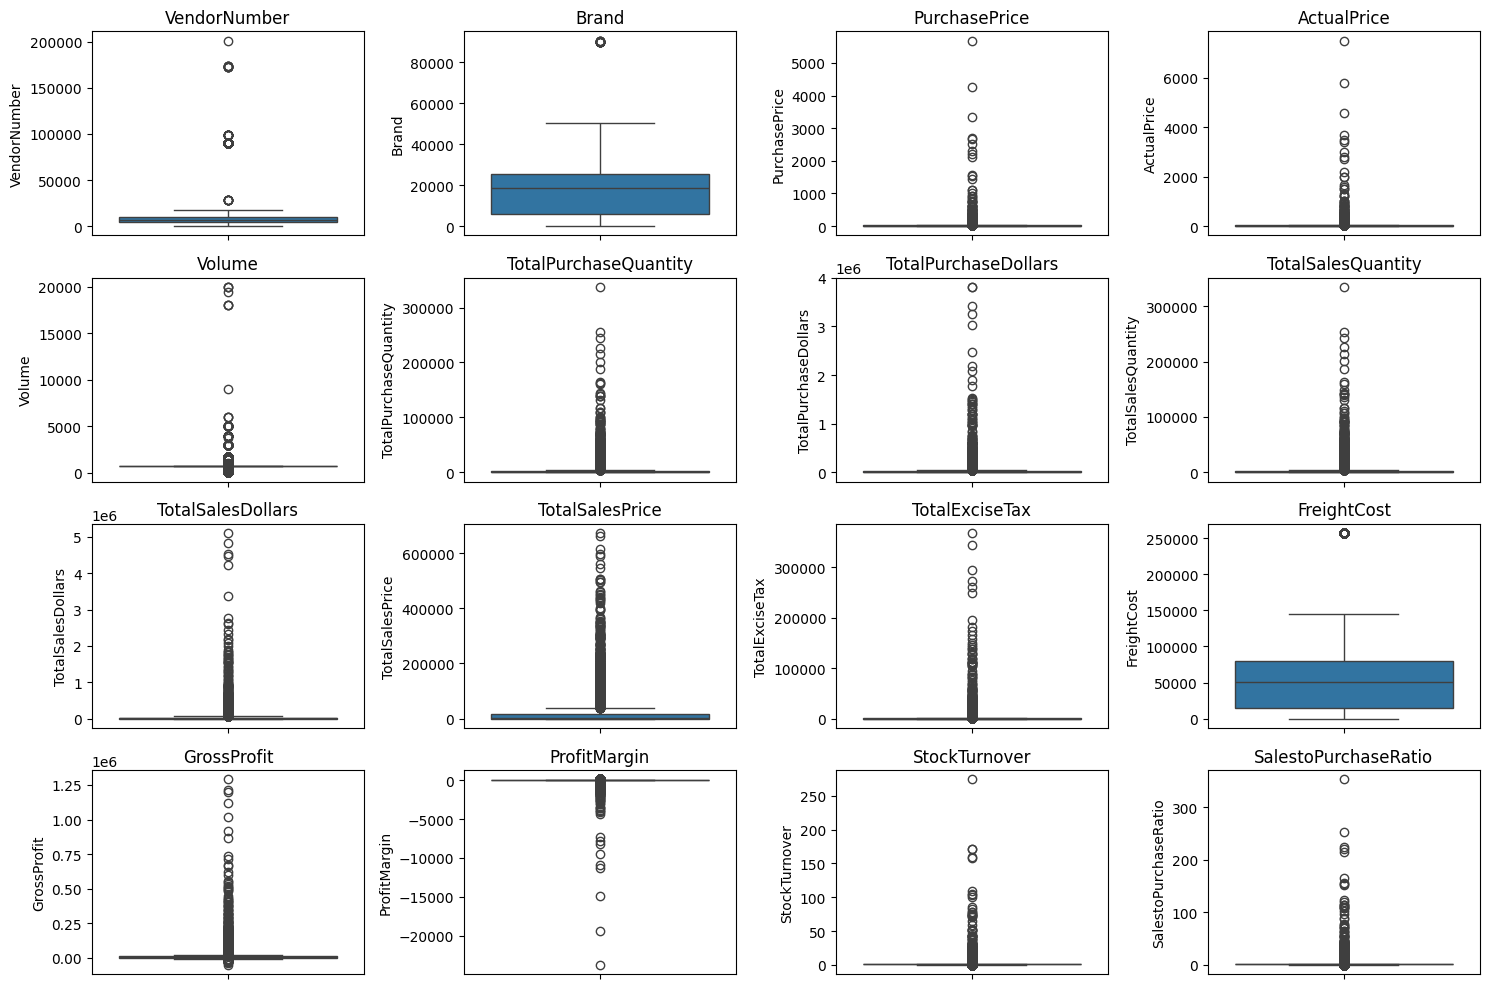

In [6]:
# Outline detectiion with boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # adjust grid layout as needed 
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# SUMMARY STATISTICS INSIGHTS:

### NAGATIIVE & ZERO VALUES:

- gross profit: minimym value is-52,002,78, indicating losses, some product or transaction may be selling at a loss high costs or selling at discountslower than the purchase price..
- profit margin: has a minimum of_, which suggests cases whare revenue is zero or even lower than costs.
- total sales quantity & sales doolars: minimum value are 0,meaning some products were purchased but never sold. these could be slow-moving or obsolete stock.


### OUTLIERS INDICATED BY HIGH STANDERD DEVIATIONS:


- purchase & actual price: the max value (s,681.81&7,499.99) are significantly higher then the mean (24.39 & 35.64), indicsting potential premium products.
- freight cost: huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- stock turnover: ranges from 0 to 274.5, implying some productssell extremely fast while other remain in stock indefinitely. value more than 1 indicates that  sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [7]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


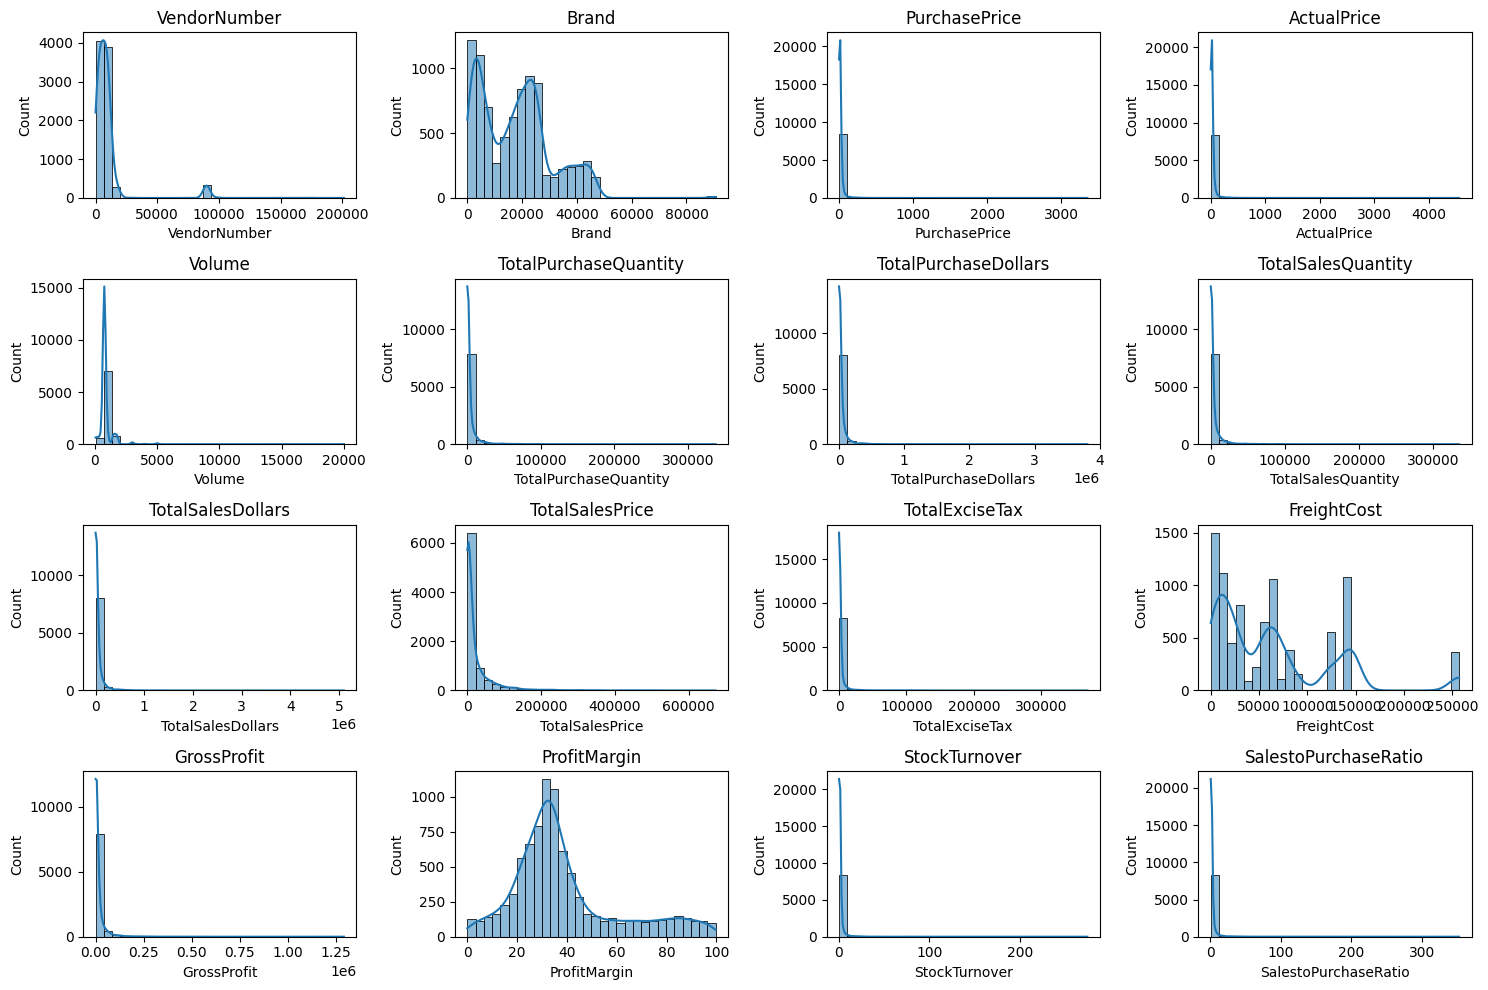

In [9]:
# Distribution Plots for Numerical columns 
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # adjust grid layout as needed 
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

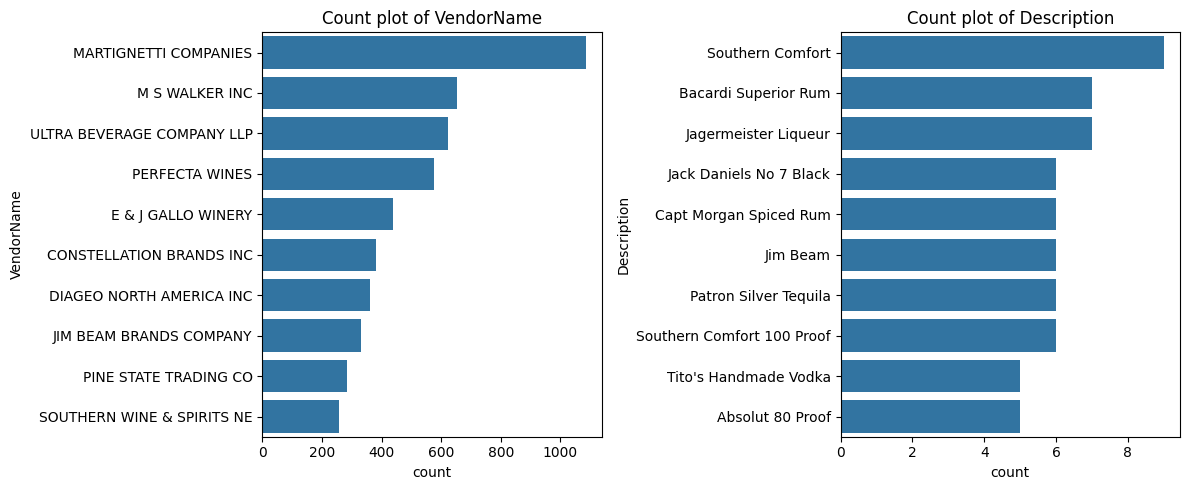

In [10]:
# count plots for categorical columns 
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts() . index[:10]) # top 10 categories
    plt.title(f"Count plot of {col}")
plt.tight_layout()
plt.show()

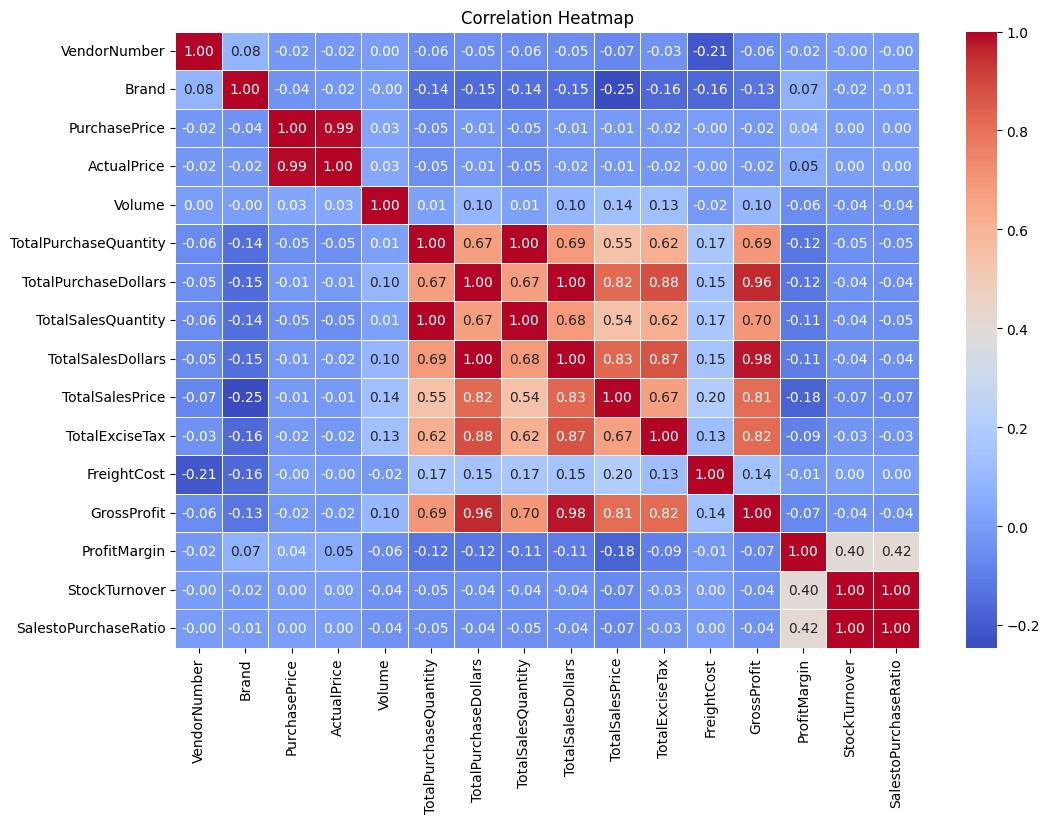

In [11]:
# correlation Heatmap
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

## CORRELATION INSIGHTS

- PurchasePrice has weak correlations with TotalSalesdollar(-0.012) and grossprofit(-0.016), suggesting that price variations do not significantly impect sales revenu or profit:
- storg correlation between total purchase quantity and total sales quantity(0.999), confirming efficient inventory turnover.
- negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margin decrease, possibly due to competitive pricing pressures.
- stockturnover has weak negative correlations with both grossprofit(-0.038) and profitmargin(-0.055), indicating that faster turnover does not nesessarily result in higher profitability.

# DATA ANALYSIS

#### identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.

In [12]:
df.columns = df.columns.str.strip()

brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

In [13]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [14]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [15]:
low_sales_threshold

np.float64(560.299)

In [16]:
high_margin_threshold

np.float64(64.97017552750113)

In [17]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)

    ]
print("Brands with Low sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [18]:
# Remove extreme values
brand_performance = brand_performance[
    (brand_performance['ProfitMargin'] > -100) &
    (brand_performance['ProfitMargin'] < 100)
]

In [19]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000]

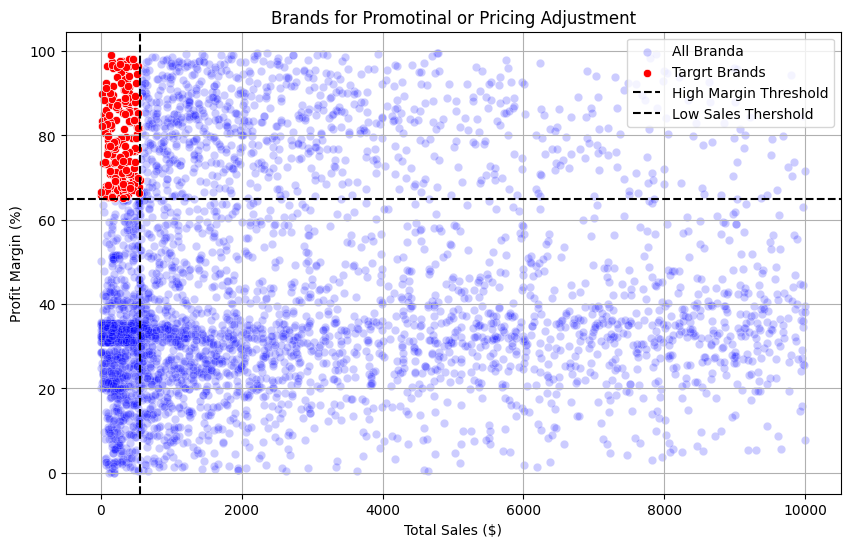

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Branda", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Targrt Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Thershold")


plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotinal or Pricing Adjustment")
plt.legend()
plt.grid(True)
plt.show()


### Which vendor and brands demonstrate the highest sales performance?

In [21]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return ster(value)

In [22]:
# top vendor & brands by sales performance
top_vendors = df.groupby("VendorName") ["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description") ["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [23]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.964747M
Tito's Handmade Vodka      7.399658M
Grey Goose Vodka           7.209608M
Capt Morgan Spiced Rum     6.356321M
Absolut 80 Proof           6.244752M
Jameson Irish Whiskey      5.715760M
Ketel One Vodka            5.070084M
Baileys Irish Cream        4.150122M
Kahlua                     3.604859M
Tanqueray                  3.456698M
Name: TotalSalesDollars, dtype: str

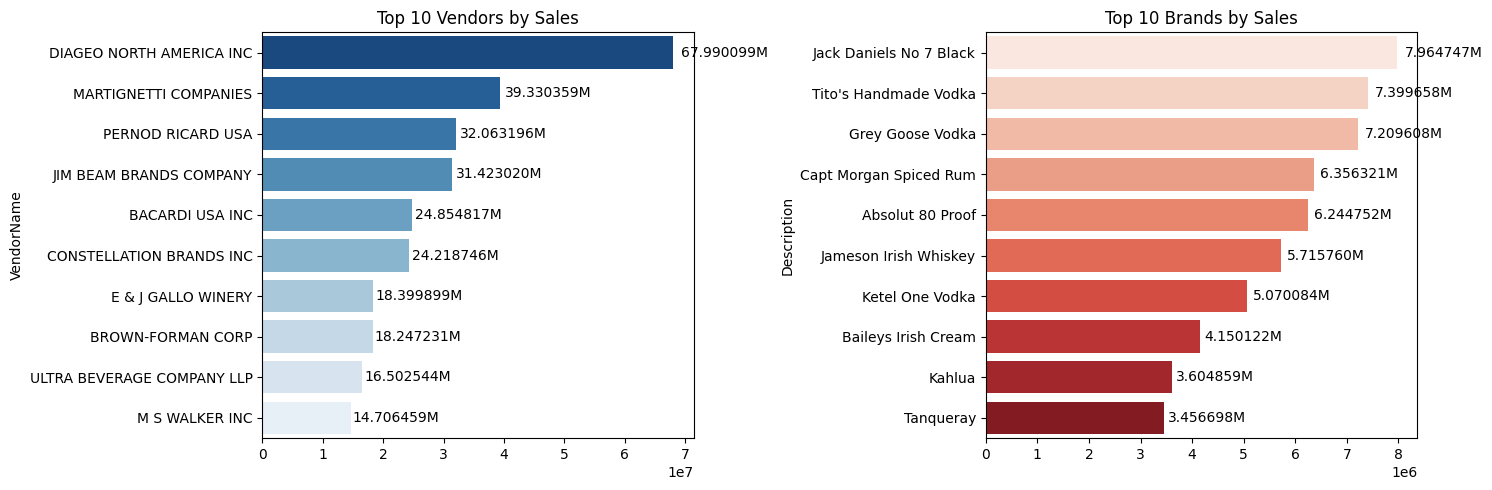

In [24]:
plt.figure(figsize=(15, 5))

# plot for top vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# plot for top barnds
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


### WHICH VENDORS CONTRIBUTE THE MOST TO TOTAL PURCHASE DOLLARS?

In [25]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars' : 'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [26]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()*100

In [27]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

In [28]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [29]:

top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.097226M,17.892873M,67.990099M,16.30
57,MARTIGNETTI COMPANIES,25.502096M,13.828264M,39.330359M,8.30
68,PERNOD RICARD USA,23.851164M,8.212032M,32.063196M,7.76
46,JIM BEAM BRANDS COMPANY,23.494304M,7.928716M,31.423020M,7.64
6,BACARDI USA INC,17.432020M,7.422797M,24.854817M,5.67
20,CONSTELLATION BRANDS INC,15.273708M,8.945038M,24.218746M,4.97
11,BROWN-FORMAN CORP,13.238939M,5.008291M,18.247231M,4.31
30,E & J GALLO WINERY,12.068539M,6.331360M,18.399899M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.167082M,5.335463M,16.502544M,3.63
53,M S WALKER INC,9.764313M,4.942146M,14.706459M,3.18


In [30]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()

In [31]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.097226M,17.892873M,67.990099M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.502096M,13.828264M,39.330359M,8.30,24.60
68,PERNOD RICARD USA,23.851164M,8.212032M,32.063196M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.494304M,7.928716M,31.423020M,7.64,40.00
6,BACARDI USA INC,17.432020M,7.422797M,24.854817M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.273708M,8.945038M,24.218746M,4.97,50.64
11,BROWN-FORMAN CORP,13.238939M,5.008291M,18.247231M,4.31,54.95
30,E & J GALLO WINERY,12.068539M,6.331360M,18.399899M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.167082M,5.335463M,16.502544M,3.63,62.51
53,M S WALKER INC,9.764313M,4.942146M,14.706459M,3.18,65.69


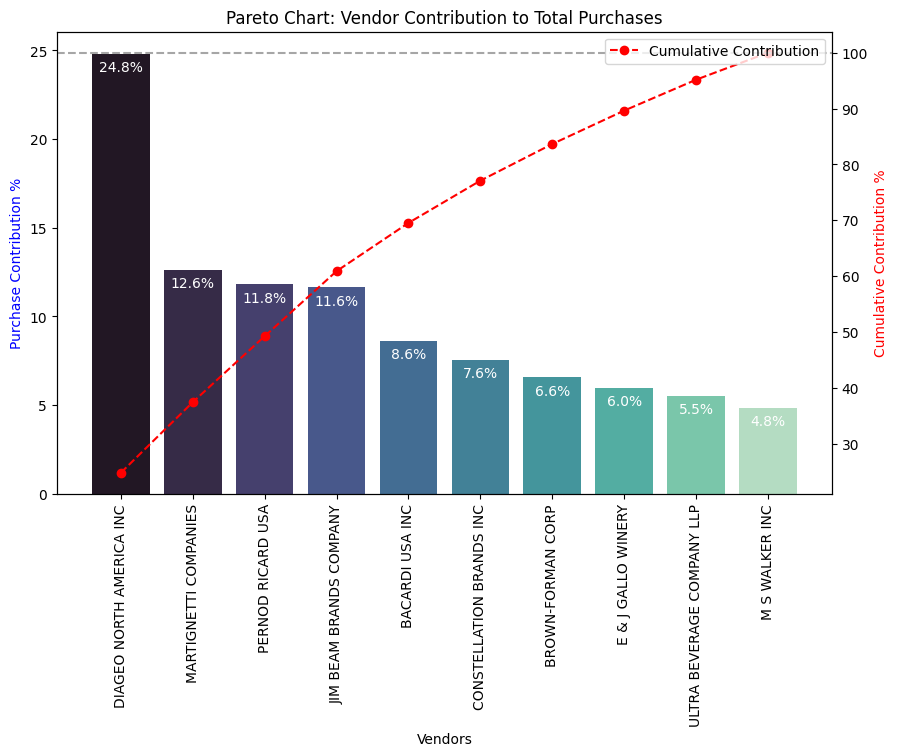

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Convert M values back to numeric
# -------------------------------
top_vendors['TotalPurchaseDollars'] = (
    top_vendors['TotalPurchaseDollars']
    .replace({'M': ''}, regex=True)
    .astype(float)
)

# -------------------------------
# Create Contribution %
# -------------------------------
top_vendors['Purchase_Contribution%'] = (
    top_vendors['TotalPurchaseDollars'] /
    top_vendors['TotalPurchaseDollars'].sum()
) * 100

# -------------------------------
# Create Cumulative Contribution %
# -------------------------------
top_vendors['Cumulative_Contribution%'] = (
    top_vendors['Purchase_Contribution%'].cumsum()
)

# -------------------------------
# Create Pareto Chart
# -------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar Plot
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['Purchase_Contribution%'],
    palette="mako",
    ax=ax1
)

# Add percentage labels on bars
for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(
        i,
        value - 1,
        f"{value:.1f}%",
        ha='center',
        fontsize=10,
        color='white'
    )

# -------------------------------
# Line Plot for Cumulative %
# -------------------------------
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution'
)

# -------------------------------
# Labels & Title
# -------------------------------
ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')

ax1.set_xlabel('Vendors')

ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

# 100% reference line
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

# Legend
ax2.legend(loc='upper right')

# Show Plot
plt.show()

### How much of total procurement is dependent on the top vendors?

In [51]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.69 %


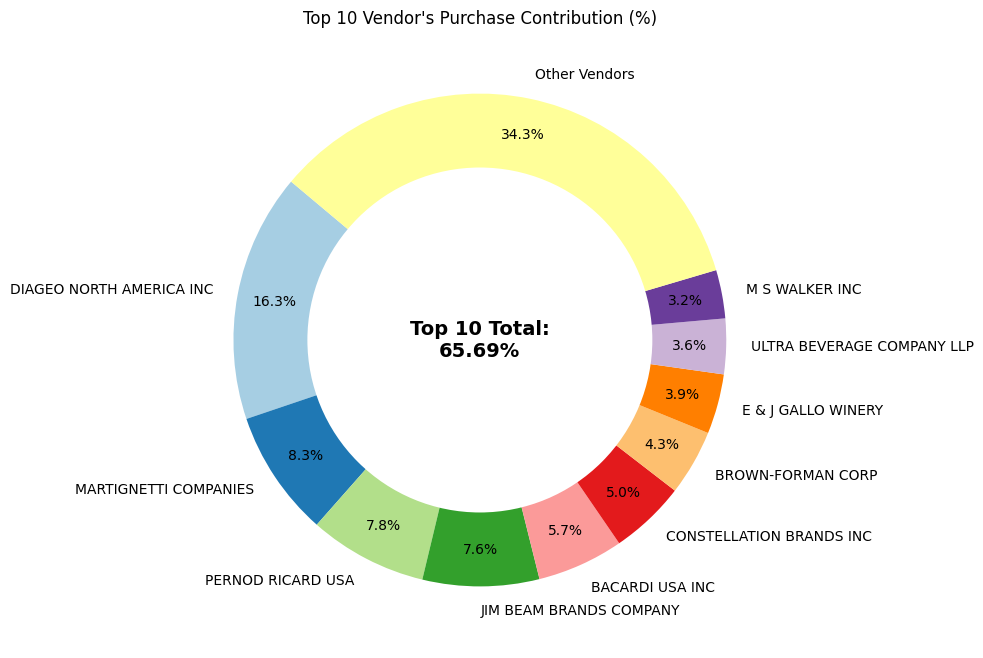

In [52]:
# total purchase of all vendors
total_purchase = vendor_performance['TotalPurchaseDollars'].sum()

# top 10 vendors by purchase
top_vendors = vendor_performance.nlargest(10, 'TotalPurchaseDollars')

# calculate contribution percentage
top_vendors['Purchase_Contribution%'] = (
    top_vendors['TotalPurchaseDollars'] / total_purchase
) * 100

# convert into list
vendors = list(top_vendors['VendorName'].values)

purchase_contributions = list(
    top_vendors['Purchase_Contribution%'].values
)

# total contribution of top 10
total_contribution = sum(purchase_contributions)

# remaining vendors contribution
remaining_contribution = 100 - total_contribution

# append other vendors
vendors.append("Other Vendors")

purchase_contributions.append(remaining_contribution)

# donut chart
fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')

fig.gca().add_artist(centre_circle)

# center text
plt.text(
    0,
    0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.show()

###  Does purchasing in bulk the unit price, and what is the optimal purchase volume for cost savings?

In [35]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [36]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small","Medium", "Lerge"])

In [37]:
df[['OrderSize', 'TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Lerge,145080
1,Lerge,164038
2,Lerge,187407
3,Lerge,201682
4,Lerge,138109
...,...,...
8559,Small,2
8560,Small,6
8561,Small,2
8562,Small,1


In [38]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Lerge,10.777625


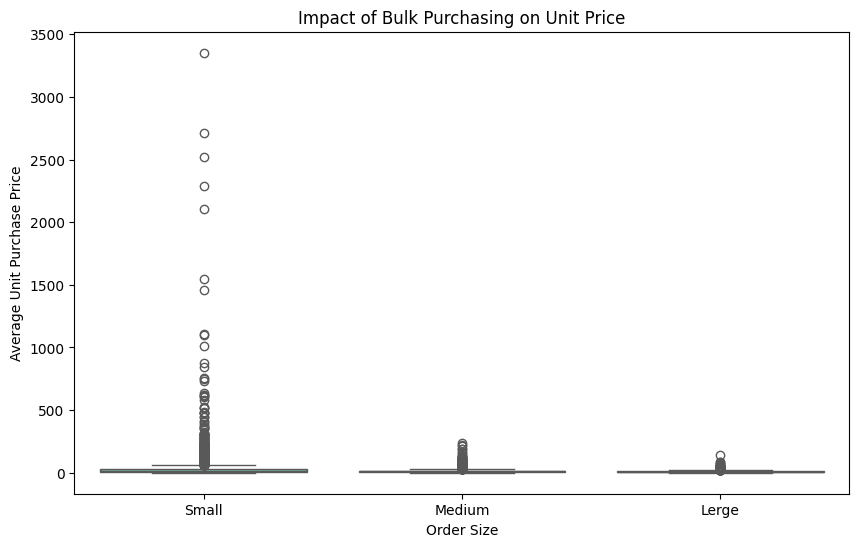

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- vendors buying in bulk (large order(size) get the lowest unit price($10.78 per unit), meaning higher margins if they can manage invetory efficiently.
- The price difference betwwen small and large order is substantial (-72% reduction in unit cost)
- This suggets thet bulk pricing startegies successfully encourage vendor to purchase in larger volumes, leaading to higher overall sales despite lower per-unit revenue.

#### WHICH VENDORS HAVE LOW INVENTORY TUTNOVER, INDICATING EXCEST STOCK AND SLOW-MOVINIG PRODUCTS?

In [40]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover' , ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


#### HOW MUCH CAPITAL IS LOCKED IN UNSOLD INVENTORY PAR VENDOR. AND WHICH VENDOR CONTRIBUTE THE MOST TO IT?

In [41]:
def Format_dollars(x):
    return f"${x:,.2f}"

In [42]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', Format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: $2,708,177.22


In [43]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendor With the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue",
    ascending=False
)

inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(Format_dollars)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,"$722,209.05"
46,JIM BEAM BRANDS COMPANY,"$554,665.63"
68,PERNOD RICARD USA,"$470,625.61"
116,WILLIAM GRANT & SONS INC,"$401,960.83"
30,E & J GALLO WINERY,"$228,282.61"
79,SAZERAC CO INC,"$198,436.41"
11,BROWN-FORMAN CORP,"$177,733.74"
20,CONSTELLATION BRANDS INC,"$133,617.62"
61,MOET HENNESSY USA INC,"$126,477.70"
77,REMY COINTREAU USA INC,"$118,598.15"


#### WHAT IS THE 95% CONFIDENCE INTERVALSFOR PROFIT MARGINS OF TOP-PERFORMING AND LOW-PERFORMING VENDORS.

In [44]:
def confidence_interval(data, confidence=0.95):

    mean_val = np.mean(data)

    std_err = np.std(data, ddof=1) / np.sqrt(len(data))

    t_critical = stats.t.ppf((1 + confidence) / 2,
                             df=len(data)-1)

    margin_of_error = t_critical * std_err

    lower_bound = mean_val - margin_of_error
    upper_bound = mean_val + margin_of_error

    return mean_val, lower_bound, upper_bound

In [45]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)

low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_profit_margin = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()

low_profit_margin = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [46]:
top_mean, top_lower, top_upper = confidence_interval(top_profit_margin)

low_mean, low_lower, low_upper = confidence_interval(low_profit_margin)

print(top_mean, top_lower, top_upper)

print(low_mean, low_lower, low_upper)

31.177912433072315 30.742063812031255 31.613761054113375
41.56916981297642 40.50141289982574 42.6369267261271


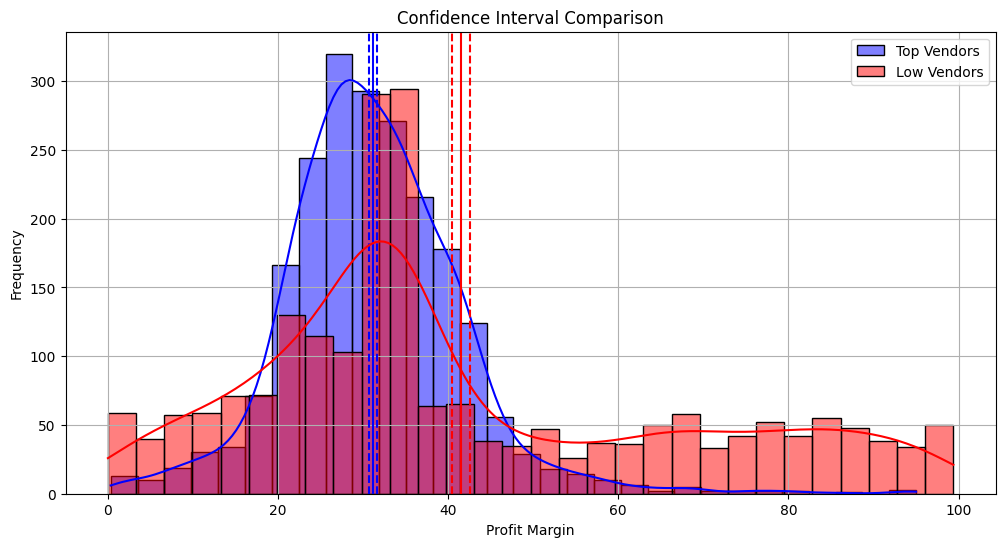

In [47]:
plt.figure(figsize=(12,6))

# Top Vendors
sns.histplot(top_profit_margin,
             kde=True,
             color="blue",
             bins=30,
             alpha=0.5,
             label="Top Vendors")

plt.axvline(top_lower,
            color="blue",
            linestyle="--")

plt.axvline(top_upper,
            color="blue",
            linestyle="--")

plt.axvline(top_mean,
            color="blue",
            linestyle="-")


# Low Vendors
sns.histplot(low_profit_margin,
             kde=True,
             color="red",
             bins=30,
             alpha=0.5,
             label="Low Vendors")

plt.axvline(low_lower,
            color="red",
            linestyle="--")

plt.axvline(low_upper,
            color="red",
            linestyle="--")

plt.axvline(low_mean,
            color="red",
            linestyle="-")

plt.title("Confidence Interval Comparison")

plt.xlabel("Profit Margin")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

- The confidence interval for low-perfromin vandors(40.48% to 42.62%) is sinfnificantly higer then of  top-performing vendors(30.74% to 31.61%).
- This suggests thet Vendors with lower ssales teand to maintanin higher profit margins, potentially due to premium pricing or lower opertional costs.
- for High-performing Vendors: if they aim to improve profitabillity, they could explore selective price adjustments, cost optimization, or bundilling strategies.
- Foe Low-Performing vendors: despite higher margins, thier low sales volume might indicate a need for better marketing, competitive pricing, or impoved distribution strategies.

#### is there a significant difference in profit maargins between top-performing and low-performing vendors?
- Hypothesis:
- H0 (Null Hypothesis):There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
- H1 (AAlternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [48]:
# Define top and low vendor groups

top_threshold = df["TotalSalesDollars"].quantile(0.75)

low_threshold = df["TotalSalesDollars"].quantile(0.25)


top_profit_margin = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()

low_profit_margin = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()


# Perform Independent T-Test

t_stat, p_value = stats.ttest_ind(top_profit_margin,
                                  low_profit_margin,
                                  equal_var=False)


# Print Results

print("T-Statistic:", t_stat)

print("P-Value:", p_value)


# Hypothesis Decision

alpha = 0.05

if p_value < alpha:

    print("Reject Null Hypothesis (H0)")
    print("There IS a significant difference in profit margins.")

else:

    print("Fail to Reject Null Hypothesis (H0)")
    print("There is NO significant difference in profit margins.")

T-Statistic: -17.66952328154073
P-Value: 2.2968978144315674e-66
Reject Null Hypothesis (H0)
There IS a significant difference in profit margins.


Low-performing vendors have significantly higher profit margins compared to top-performing vendors, suggesting that high sales volume vendors may operate with lower margins due to competitive pricing or discount strategies.

In [49]:
print("Top Vendor Mean Profit Margin:",
      top_profit_margin.mean())

print("Low Vendor Mean Profit Margin:",
      low_profit_margin.mean())

Top Vendor Mean Profit Margin: 31.177912433072315
Low Vendor Mean Profit Margin: 41.56916981297642


In [50]:
vendor_performance.to_csv("vendor_performance_cleaned.csv", index=False)